# Cuaderno 07: Alineación Múltiple Progresiva (MSA)

## 1. Competencias
### 1.1 Competencias del curso
Conoce, comprende y aplica los conceptos fundamentales de la Bioinformática.

### 1.2 Competencia del laboratorio
Implementar un algoritmo de alineamiento múltiple progresivo que permita
comparar secuencias biológicas, construir árboles guía mediante UPGMA y
generar alineamientos múltiples para el análisis de conservación y parentesco
molecular.

## 2. Equipos y Materiales
- Un computador
- Lenguaje de programación

## 3. Marco Teórico

### 3.1 Multiple Sequence Alignment (MSA)

MSA es una extensión de la alineación de secuencias por pares que alinea
**múltiples secuencias simultáneamente**. Su objetivo es optimizar la
alineación de k-secuencias para:
- Identificar similitudes y patrones generales
- Extraer información de consenso
- Revelar relaciones evolutivas
- Inferir relaciones funcionales entre secuencias

### 3.2 Puntuación SP (Sum of Pairs)

La puntuación de una columna $m_i$ se define como la suma de puntuaciones por pares:

$$S(m_i) = \sum_{k < l} s(m_i^k, m_i^l)$$

El total del MSA es:

$$\text{Score} = \sum_{i=1}^{N} S(m_i) + \Delta$$

### 3.3 Construcción del Árbol Guía (UPGMA)

Se fusionan las secuencias de menor distancia iterativamente. La distancia
entre el nuevo grupo $C_{ij}$ y un grupo $C_k$ se calcula con promedio ponderado:

$$d(C_{ij}, C_k) = \frac{n_i \cdot d(C_i, C_k) + n_j \cdot d(C_j, C_k)}{n_i + n_j}$$

### 3.4 Ejemplo del árbol guía (de la teoría)

Dado el ejemplo de la clase con S1..S5, la matriz de distancias inicial es:

|    | S1 | S2 | S3 | S4 | S5 |
|----|----|----|----|----|-----|
| S1 | 0  | 4  | 6  | 5  | 2  |
| S2 |    | 0  | 5  | 7  | 6  |
| S3 |    |    | 0  | 8  | 7  |
| S4 |    |    |    | 0  | 5  |
| S5 |    |    |    |    | 0  |

El par más cercano es S1-S5 (distancia=2) -> se fusionan en S6.
Luego S6-S4 -> S7, luego S2-S3 -> S8, finalmente S7-S8 -> S9.

### 3.5 Alineación progresiva con símbolo neutro X

Durante la alineación progresiva los gaps insertados se representan
temporalmente con **X** para que no tengan penalización en pasos posteriores.
Al final todos los X se reemplazan por el símbolo de gap `-`.

**Ejemplo de la clase:**
```
S1: -ATTTA-CGCCT    ->   S1: XATTTAXCGCCT
S5: AATTTACCGCCT        S5: AATTTACCGCCT
```


## Funciones previas
### Parámetros de puntuación

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import time, os
from dataclasses import dataclass, field
from typing import Optional
from Bio import Entrez, SeqIO


@dataclass
class ScoreParams:
    """Parámetros del sistema de puntuación — modelo de costo unitario del laboratorio.

    El laboratorio pide: s(a,a)=0, s(a,b)=1, s(X,*)=0
    NW maximiza, así que negamos: match=0, mismatch=-1, gap=-1.
    La distancia bruta se obtiene como -(score NW), que equivale
    al número mínimo de sustituciones + gaps (distancia de edición).
    """
    match:    int = 0    # s(a,a) = 0 costo
    mismatch: int = -1   # s(a,b) = 1 costo  -> negado para maximizar
    gap:      int = -1   # gap    = 1 costo  -> negado para maximizar

    def score(self, a: str, b: str) -> int:
        """Retorna la puntuación de alinear dos caracteres.
           El símbolo neutro X tiene costo 0 contra cualquier cosa.
        """
        if a == 'X' or b == 'X':
            return 0    # símbolo neutro del MSA progresivo
        return self.match if a.upper() == b.upper() else self.mismatch


params = ScoreParams()
print(f"Modelo de costo unitario (laboratorio):")
print(f"  s(a,a) = {-params.match}  (match    -> 0 penalización)")
print(f"  s(a,b) = {-params.mismatch}  (mismatch -> 1 penalización)")
print(f"  gap    = {-params.gap}  (gap      -> 1 penalización)")
print(f"  s(X,*) = 0  (neutro → sin penalización)")


Modelo de costo unitario (laboratorio):
  s(a,a) = 0  (match    → 0 penalización)
  s(a,b) = 1  (mismatch → 1 penalización)
  gap    = 1  (gap      → 1 penalización)
  s(X,*) = 0  (neutro → sin penalización)


### Estructura de resultado de alineamiento

In [2]:
@dataclass
class AlignmentResult:
    """Encapsulamos el resultado de un alineamiento"""
    seq1_aligned: str
    seq2_aligned: str
    score:        int
    matrix:       np.ndarray
    algorithm:    str

    @property
    def identity(self) -> float:
        matches = sum(
            a == b for a, b in zip(self.seq1_aligned, self.seq2_aligned)
            if a != '-' and b != '-' and a != 'X' and b != 'X'
        )
        length = max(len(self.seq1_aligned), len(self.seq2_aligned))
        return matches / length * 100 if length > 0 else 0.0

    def print_alignment(self, line_width: int = 60):
        s1, s2 = self.seq1_aligned, self.seq2_aligned
        mid = ''
        for a, b in zip(s1, s2):
            if a == '-' or b == '-': mid += ' '
            elif a == 'X' or b == 'X': mid += '~'
            elif a.upper() == b.upper(): mid += '|'
            else: mid += '.'
        print(f"  Algoritmo  : {self.algorithm}")
        print(f"  Score      : {self.score}")
        print(f"  Identidad  : {self.identity:.1f}%")
        print(f"  Longitud   : {len(s1)} nt")
        print()
        pos = 0
        while pos < len(s1):
            blk = slice(pos, pos + line_width)
            print(f"  Seq1 {pos+1:>5}  {s1[blk]}")
            print(f"              {mid[blk]}")
            print(f"  Seq2 {pos+1:>5}  {s2[blk]}")
            print()
            pos += line_width


### Algoritmo Needleman-Wunsch (base del MSA)

In [3]:
class NeedlemanWunsch:
    """
    Alineamiento global.
    Modificado para MSA: el símbolo X no tiene ninguna penalizacion
    
    Con el modelo unitario (match=0, mismatch=-1, gap=-1):
      - NW maximiza -> score optimo es 0 o negativo.
      - distance() devuelve -score, que es la distancia de edición
        (número de mismatches + gaps), igual que en la teoría.
    """
    def __init__(self, params: ScoreParams = ScoreParams()):
        self.params = params

    def align(self, seq1: str, seq2: str) -> "AlignmentResult":
        n, m = len(seq1), len(seq2)
        H = np.zeros((n + 1, m + 1), dtype=int)
        T = np.full((n + 1, m + 1), '', dtype=object)

        for i in range(1, n + 1): H[i][0] = i * self.params.gap; T[i][0] = 'U'
        for j in range(1, m + 1): H[0][j] = j * self.params.gap; T[0][j] = 'L'

        for i in range(1, n + 1):
            for j in range(1, m + 1):
                d = H[i-1][j-1] + self.params.score(seq1[i-1], seq2[j-1])
                u = H[i-1][j]   + self.params.gap
                l = H[i][j-1]   + self.params.gap
                best = max(d, u, l)
                H[i][j] = best
                # Prioridad: diagonal > arriba > izquierda (desempate estable)
                if best == d:   T[i][j] = 'D'
                elif best == u: T[i][j] = 'U'
                else:           T[i][j] = 'L'

        aln1 = aln2 = ''
        i, j = n, m
        while i > 0 or j > 0:
            d = T[i][j]
            if d == 'D': aln1 = seq1[i-1]+aln1; aln2 = seq2[j-1]+aln2; i -= 1; j -= 1
            elif d == 'U': aln1 = seq1[i-1]+aln1; aln2 = '-'+aln2; i -= 1
            else: aln1 = '-'+aln1; aln2 = seq2[j-1]+aln2; j -= 1

        return AlignmentResult(aln1, aln2, int(H[n][m]), H, "Needleman-Wunsch")

    def distance(self, seq1: str, seq2: str) -> float:
        """Distancia de edicipn = número de mismatches + gaps.
           Con el modelo unitario es exactamente -score(NW).
        """
        res = self.align(seq1, seq2)
        return float(-res.score)   # distancia bruta, sin normalizar

print("NeedlemanWunsch listo (modelo unitario, distancia = -score).")


NeedlemanWunsch listo (modelo unitario, distancia = -score).


## Descarga y lectura de secuencias

In [4]:
def fetch_fasta_from_ncbi(accession: str, email: str,
                           save_path: Optional[str] = None,
                           db: str = "nucleotide"):
    """Descarga un registro FASTA desde NCBI."""
    Entrez.email = email
    handle = Entrez.efetch(db=db, id=accession, rettype="fasta", retmode="text")
    record = SeqIO.read(handle, "fasta")
    handle.close()
    if save_path:
        os.makedirs(os.path.dirname(save_path) or '.', exist_ok=True)
        with open(save_path, "w") as f:
            SeqIO.write(record, f, "fasta")
    return record.id, record.description, str(record.seq)


def leer_fasta(filepath: str) -> tuple[str, str, str]:
    """Lee un archivo FASTA y retorna (id, descripción, secuencia)."""
    with open(filepath, 'r') as f:
        lineas = f.readlines()
    header = lineas[0].strip()
    seq_id = header.split()[0][1:]
    desc   = ' '.join(header.split()[1:])
    seq    = ''.join(l.strip() for l in lineas[1:]).upper()
    return seq_id, desc, seq


@dataclass
class Secuencia:
    id: str; descripcion: str; secuencia: str

    @property
    def longitud(self) -> int: return len(self.secuencia)

    def __str__(self):
        return (f" ID: {self.id}\n Longitud: {self.longitud} pb\n"
                f" Desc: {self.descripcion[:60]}...\n"
                f" Inicio: {self.secuencia[:40]}...")

print("Funciones de descarga y lectura listas.")


Funciones de descarga y lectura listas.


## Descarga de secuencias para el laboratorio

Las secuencias sugeridas son 200–300 nt de organismos relacionados:
- *Escherichia coli* K-12, NC_000913.2
- *Salmonella enterica* LT2, NC_003197.2
- *Shigella flexneri*, NC_004337.2
- *Klebsiella pneumoniae*, NC_009648.1
- *Enterobacter cloacae*, NZ_CP013070.1

Usamos los primeros 250 nt de cada genoma para que el MSA sea manejable.


In [5]:
EMAIL = "rhyi888@gmail.com"   # reemplaza con tu email
DATA_DIR = "data"
os.makedirs(DATA_DIR, exist_ok=True)

# Accessions de los 5 organismos sugeridos
ACCESSIONS_MSA = {
    "E_coli"       : "NC_000913.2",
    "Salmonella"   : "NC_003197.2",
    "Shigella"     : "NC_004337.2",
    "Klebsiella"   : "NC_009648.1",
    "Enterobacter" : "NZ_CP013070.1",
}

secuencias_msa = {}   # nombre -> objeto Secuencia

for nombre, acc in ACCESSIONS_MSA.items():
    fasta_path = os.path.join(DATA_DIR, f"{acc}.fasta")
    if os.path.exists(fasta_path):
        seq_id, desc, seq = leer_fasta(fasta_path)
        print(f"  {nombre:<15} cargado desde disco ({len(seq):,} pb)")
    else:
        print(f"  {nombre:<15} descargando {acc}...", end=" ", flush=True)
        try:
            seq_id, desc, seq = fetch_fasta_from_ncbi(acc, EMAIL, save_path=fasta_path)
            print(f"OK ({len(seq):,} pb)")
        except Exception as e:
            print(f"ERROR: {e}")
            continue

    # Usamos los primeros 250 nt para el MSA
    secuencias_msa[nombre] = Secuencia(id=seq_id, descripcion=desc, secuencia=seq[:250])

print()
print("Secuencias cargadas para MSA:")
for nombre, sec in secuencias_msa.items():
    print(f"  {nombre:<15} {sec.longitud} pb  {sec.secuencia[:40]}...")


  E_coli          cargado desde disco (4,639,675 pb)
  Salmonella      cargado desde disco (4,857,450 pb)
  Shigella        cargado desde disco (4,607,202 pb)
  Klebsiella      cargado desde disco (5,315,120 pb)
  Enterobacter    cargado desde disco (3,654,322 pb)

Secuencias cargadas para MSA:
  E_coli          250 pb  AGCTTTTCATTCTGACTGCAACGGGCAATATGTCTCTGTG...
  Salmonella      250 pb  AGAGATTACGTCTGGTTGCAAGAGATCATGACAGGGGGAA...
  Shigella        250 pb  AGCTTTTCATTCTGACTGCAACGGGCAATATGTCTCTGTG...
  Klebsiella      250 pb  ATGGATGTGTATGCTGTTCTATGAGCTGGTTTTCCGCCGA...
  Enterobacter    250 pb  ATAACGACAAAAATATAATTATATTCCCGTCATGTTATCC...


## 4. Ejercicios

#### Ejercicio 1: Implemente la Alineación de Múltiples secuencias en un lenguaje de programación

**Paso 1: Construir la matriz de distancias por pares**

Calculamos la distancia entre cada par de secuencias usando NW.
La distancia se normaliza entre 0 (idénticas) y 1 (sin similitud).


In [6]:
# Demostración con el ejemplo de la teoría + impresión paso a paso
print("Demostracion, ejemplo de la clase")
print("="*60)

seqs_demo = {
    "S1": "ATTTACGCCT",
    "S2": "TTAAGCCAT",
    "S3": "TTAATTAACC",
    "S4": "ATTTTCCGGA",
    "S5": "AATTTACCGCCT",
}

nw_demo = NeedlemanWunsch(params)
nombres_demo = list(seqs_demo.keys())
n_demo = len(nombres_demo)
dist_demo = np.zeros((n_demo, n_demo))

for i in range(n_demo):
    for j in range(i+1, n_demo):
        s1 = seqs_demo[nombres_demo[i]]
        s2 = seqs_demo[nombres_demo[j]]
        d  = nw_demo.distance(s1, s2)
        dist_demo[i][j] = dist_demo[j][i] = d

def imprimir_matriz(nombres_m, mat, titulo="Matriz de distancias"):
    print(f"  {titulo}:")
    ancho = max(len(n) for n in nombres_m) + 1
    print(f"  {'':{ancho}}", end="")
    for n in nombres_m: print(f"  {n:>6}", end="")
    print()
    for i, ni in enumerate(nombres_m):
        print(f"  {ni:{ancho}}", end="")
        for j in range(len(nombres_m)):
            v = mat[i][j]
            print(f"  {v:>6.1f}", end="")
        print()
    print()

imprimir_matriz(nombres_demo, dist_demo, "Matriz inicial (distancias de edición)")
print("  Valores esperados según la teoría:")
print("  d(S1,S2)=4  d(S1,S3)=6  d(S1,S4)=5  d(S1,S5)=2")
print("  d(S2,S3)=5  d(S2,S4)=7  d(S2,S5)=6")
print("  d(S3,S4)=8  d(S3,S5)=7  d(S4,S5)=5")


DEMOSTRACIÓN — Ejemplo de la clase
  Matriz inicial (distancias de edición):
           S1      S2      S3      S4      S5
  S1      0.0     4.0     6.0     5.0     2.0
  S2      4.0     0.0     5.0     7.0     6.0
  S3      6.0     5.0     0.0     8.0     7.0
  S4      5.0     7.0     8.0     0.0     5.0
  S5      2.0     6.0     7.0     5.0     0.0

  Valores esperados según la teoría:
  d(S1,S2)=4  d(S1,S3)=6  d(S1,S4)=5  d(S1,S5)=2
  d(S2,S3)=5  d(S2,S4)=7  d(S2,S5)=6
  d(S3,S4)=8  d(S3,S5)=7  d(S4,S5)=5


MATRIZ DE DISTANCIAS con Secuencias reales (250 nt)
                            E_coli  Salmonella    Shigella  Klebsiella  Enterobact
  E_coli                    0.0000     64.0000      0.0000     86.0000    143.0000
  Salmonella               64.0000      0.0000     64.0000     77.0000    145.0000
  Shigella                  0.0000     64.0000      0.0000     86.0000    143.0000
  Klebsiella               86.0000     77.0000     86.0000      0.0000    137.0000
  Enterobacter            143.0000    145.0000    143.0000    137.0000      0.0000

Visualización de la matriz de distancias:


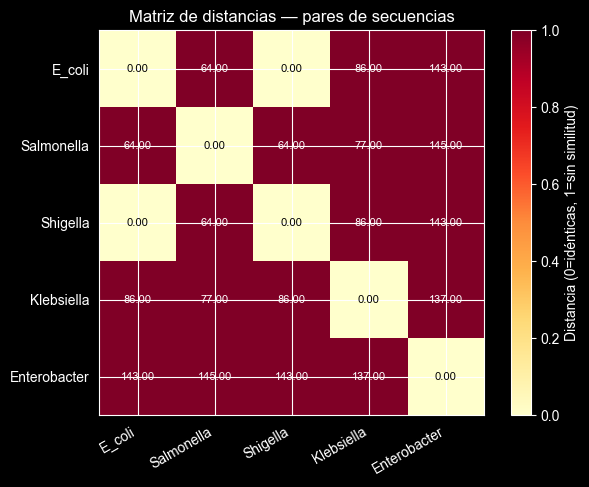

In [7]:
# Ahora con las secuencias reales descargadas
print("Matriz de distancias con Secuencias reales (250 nt)")
print("="*60)

nw = NeedlemanWunsch(params)
nombres = list(secuencias_msa.keys())
seqs    = [secuencias_msa[n].secuencia for n in nombres]
N       = len(nombres)

dist_matrix = np.zeros((N, N))
for i in range(N):
    for j in range(i+1, N):
        d = nw.distance(seqs[i], seqs[j])
        dist_matrix[i][j] = dist_matrix[j][i] = round(d, 4)

# Imprimir
print(f"  {'':20}", end="")
for n in nombres: print(f"  {n[:10]:>10}", end="")
print()
for i, ni in enumerate(nombres):
    print(f"  {ni:<20}", end="")
    for j in range(N):
        print(f"  {dist_matrix[i][j]:>10.4f}", end="")
    print()

print()
print("Visualización de la matriz de distancias:")
fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(dist_matrix, cmap='YlOrRd', vmin=0, vmax=1)
plt.colorbar(im, ax=ax, label='Distancia (0=idénticas, 1=sin similitud)')
ax.set_xticks(range(N)); ax.set_xticklabels(nombres, rotation=30, ha='right')
ax.set_yticks(range(N)); ax.set_yticklabels(nombres)
for i in range(N):
    for j in range(N):
        ax.text(j, i, f"{dist_matrix[i][j]:.2f}",
                ha='center', va='center', fontsize=8,
                color='white' if dist_matrix[i][j] > 0.6 else 'black')
ax.set_title("Matriz de distancias, pares de secuencias")
plt.savefig("data/dist_matrix.png",dpi=130,bbox_inches='tight')
plt.show()


#### Ejercicio 2: Construya el Árbol guía teniendo en cuenta los siguientes pasos:
Implementamos UPGMA: en cada paso fusionamos los dos grupos de menor
distancia y actualizamos la matriz con promedio ponderado por tamaño.

- Paso 1: Construya la matriz de distancia de todas las secuencias utilizando Needleman-Wunsch
- Paso 2: Seleccione las 2 secuencias con la menor distancia y cree un nuevo agrupamiento
- Paso 3: Vuelva a calcular la matriz de distancias teniendo en consideración el metodo UPGMA
- Paso 4: Repita el proceso hasta tener el árbol guía

In [8]:
def construir_arbol_upgma(nombres: list, dist: np.ndarray,
                           verbose: bool = False) -> list:
    """
    UPGMA: fusionamos de forma iterativa los dos grupos de menor distancia
    Retorna lista de pasos: [(nombre_nuevo, grupo_a, grupo_b, distancia), ...]
    
    verbose=True imprime cada matriz intermedia (solo para nuestros ejemplos cortos).
    """
    grupos  = list(nombres)
    tamanos = [1] * len(nombres)
    D = dist.copy().astype(float)
    pasos = []
    step  = 0

    if verbose:
        from copy import deepcopy

    while len(grupos) > 1:
        n = len(grupos)
        min_d = np.inf; idx_a = idx_b = -1
        for i in range(n):
            for j in range(i+1, n):
                if D[i][j] < min_d:
                    min_d = D[i][j]; idx_a = i; idx_b = j

        nombre_nuevo = f"({grupos[idx_a]}+{grupos[idx_b]})"
        pasos.append((nombre_nuevo, grupos[idx_a], grupos[idx_b], round(min_d, 4)))
        step += 1

        print(f"  Paso {step}: fusionar '{grupos[idx_a]}' y '{grupos[idx_b]}'"
              f"  d={min_d:.2f}  -> {nombre_nuevo}")

        ni, nj = tamanos[idx_a], tamanos[idx_b]
        old_idx = [k for k in range(n) if k not in (idx_a, idx_b)]
        nuevas_dist = [
            (ni * D[idx_a][k] + nj * D[idx_b][k]) / (ni + nj)
            for k in old_idx
        ]

        nuevos_grupos  = [grupos[k] for k in old_idx] + [nombre_nuevo]
        nuevos_tamanos = [tamanos[k] for k in old_idx] + [ni + nj]

        m = len(nuevos_grupos)
        D_nuevo = np.zeros((m, m))
        for i2, oi in enumerate(old_idx):
            for j2, oj in enumerate(old_idx):
                D_nuevo[i2][j2] = D[oi][oj]
        for i2 in range(m - 1):
            D_nuevo[i2][m-1] = D_nuevo[m-1][i2] = nuevas_dist[i2]

        grupos  = nuevos_grupos
        tamanos = nuevos_tamanos
        D       = D_nuevo

        if verbose and len(grupos) > 1:
            print()
            ancho = max(len(g) for g in grupos) + 1
            print(f"    Nueva matriz tras fusión:")
            print(f"    {'':{ancho}}", end="")
            for g in grupos: print(f"  {g[:]:>8}", end="")
            print()
            for i2, gi in enumerate(grupos):
                print(f"    {gi:{ancho}}", end="")
                for j2 in range(len(grupos)):
                    print(f"  {D[i2][j2]:>8.2f}", end="")
                print()
            print()

    return pasos


print("Arbol guiacon el ejemplo de la clase (verbose)")
print("="*60)
pasos_demo = construir_arbol_upgma(list(seqs_demo.keys()), dist_demo, verbose=True)

print()
print("Arbol guia de Secuencias reales")
print("="*60)
pasos_reales = construir_arbol_upgma(nombres, dist_matrix)


ÁRBOL GUÍA — Ejemplo de la clase (verbose)
  Paso 1: fusionar 'S1' y 'S5'  d=2.00  → (S1+S5)

    Nueva matriz tras fusión:
                    S2        S3        S4   (S1+S5)
    S2            0.00      5.00      7.00      5.00
    S3            5.00      0.00      8.00      6.50
    S4            7.00      8.00      0.00      5.00
    (S1+S5)       5.00      6.50      5.00      0.00

  Paso 2: fusionar 'S2' y 'S3'  d=5.00  → (S2+S3)

    Nueva matriz tras fusión:
                    S4   (S1+S5)   (S2+S3)
    S4            0.00      5.00      7.50
    (S1+S5)       5.00      0.00      5.75
    (S2+S3)       7.50      5.75      0.00

  Paso 3: fusionar 'S4' y '(S1+S5)'  d=5.00  → (S4+(S1+S5))

    Nueva matriz tras fusión:
                    (S2+S3)  (S4+(S1+
    (S2+S3)            0.00      6.33
    (S4+(S1+S5))       6.33      0.00

  Paso 4: fusionar '(S2+S3)' y '(S4+(S1+S5))'  d=6.33  → ((S2+S3)+(S4+(S1+S5)))

ÁRBOL GUÍA — Secuencias reales
  Paso 1: fusionar 'E_coli' y 'Shigell

### Ejercicios 3, 4 , 5, 6 MSA Progresivo

Siguiendo el árbol guía:
- **Ejercicio 3:** Fusionar secuencias según el árbol guía
- **Ejercicio 4:** Para calcular las distancias de una secuencia a un grupo debe de realizar la implementación del algoritmo Needleman-Wunsch modificado con soporte para valores X (el modelo de costo unitario (s(a, a) = 0 y s(a, b) = 1, s(X, a) = s(X, b) = 0))
- **Ejercicio 5:** Repita el proceso hasta obtener todas las secuencias alineadas de la misma longitud
- **Ejercicio 6:** Finalmente remueva los valores agregados (X) y muestre el conjunto de secuencias alineados
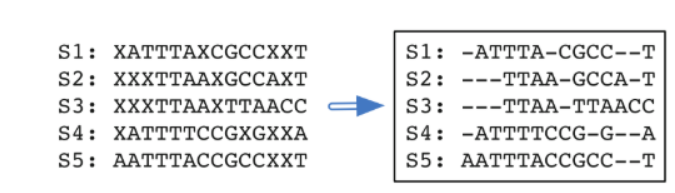

El símbolo **X** reemplaza temporalmente los gaps durante el proceso progresivo.

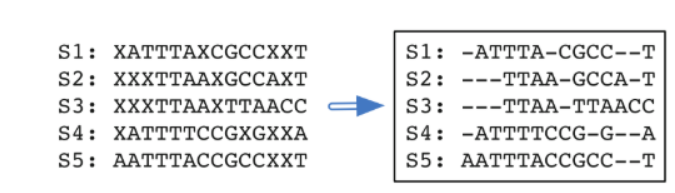

In [9]:
class MSAProgresivo:
    """
    Alineación Múltiple Progresiva basada en UPGMA + Needleman-Wunsch.

    Pasos:
    1. Calculamos la matriz de distancias por pares (NW, modelo unitario)
    2. Construir el árbol guía (UPGMA)
    3. Alinear progresivamente siguiendo el árbol
       - gaps temporales → símbolo neutro X (costo 0)
       - al final → reemplazar X por -
    """

    def __init__(self, params: ScoreParams = ScoreParams()):
        self.params = params
        self.nw     = NeedlemanWunsch(params)

    def _propagar_gaps(self, grupo: list, seq_aln: str) -> list:
        """
        Dado un grupo de secuencias y la secuencia alineada de referencia
        (que puede contener '-' indicando dónde insertar X), propaga
        esa misma estructura de gaps a todas las secuencias del grupo.

        seq_aln tiene la misma longitud para todos los miembros del grupo
        excepto por los gaps nuevos que se insertan.
        El grupo ya puede contener 'X' de pasos anteriores; se insertan
        nuevas 'X' en las posiciones donde seq_aln tiene '-'.
        """
        nuevo_grupo = []
        for seq in grupo:
            nueva = []
            idx = 0          # cursor sobre seq (que ya tiene X de antes)
            for c in seq_aln:
                if c == '-':
                    nueva.append('X')   # gap nuevo → símbolo neutro
                else:
                    # Avanzamos sobre seq hasta el siguiente carácter real
                    # (los X ya presentes en seq se copian tal cual)
                    if idx < len(seq):
                        nueva.append(seq[idx])
                        idx += 1
                    else:
                        nueva.append('X')
            nuevo_grupo.append(''.join(nueva))
        return nuevo_grupo

    def _alinear_dos_grupos(self,
                             grupo_a: list,
                             grupo_b: list) -> tuple:
        """
        Alinea grupo_a con grupo_b.
        Prueba todos los pares (a_i, b_j); el de mejor score
        determina la estructura de gaps que se propaga a todoo el grupo
        """
        mejor_score = -np.inf
        mejor_a_aln = mejor_b_aln = None

        for sa in grupo_a:
            for sb in grupo_b:
                res = self.nw.align(sa, sb)
                if res.score > mejor_score:
                    mejor_score  = res.score
                    mejor_a_aln  = res.seq1_aligned
                    mejor_b_aln  = res.seq2_aligned

        grupo_a_nuevo = self._propagar_gaps(grupo_a, mejor_a_aln)
        grupo_b_nuevo = self._propagar_gaps(grupo_b, mejor_b_aln)
        return grupo_a_nuevo, grupo_b_nuevo

    def alinear(self, secuencias: dict, verbose_demo: bool = False) -> dict:
        """
        Ejecuta el MSA completo.

        Parámetros
        ----------
        secuencias     : dict {nombre: secuencia}
        verbose_demo   : True → imprime matrices y alineamientos intermedios
                         (solo para ejemplos cortos, sería inviable con reales)

        Retorna
        -------
        dict {nombre: secuencia_alineada}  con '-' en lugar de gaps
        """
        nombres = list(secuencias.keys())
        seqs    = [secuencias[n] for n in nombres]
        N       = len(nombres)

        print(f"MSA de {N} secuencias")
        print(f"  Longitudes iniciales: {[len(s) for s in seqs]}")

        # --- Paso 1: Matriz de distancias ---
        print("\n  [1] Calculando matriz de distancias...")
        dist = np.zeros((N, N))
        for i in range(N):
            for j in range(i+1, N):
                d = self.nw.distance(seqs[i], seqs[j])
                dist[i][j] = dist[j][i] = d

        # --- Paso 2: Árbol guía UPGMA ---
        print("  [2] Construyendo árbol guía (UPGMA)...")

        # Estado activo del MSA: cada nombre → lista de secuencias alineadas
        grupos_dict   = {n: [s] for n, s in zip(nombres, seqs)}
        # Tracking: nombre_grupo → lista de nombres originales
        miembros_dict = {n: [n] for n in nombres}
        tamanos = {n: 1 for n in nombres}
        D   = dist.copy().astype(float)
        nms = list(nombres)
        paso = 0

        while len(nms) > 1:
            n_act = len(nms)
            min_d = np.inf; idx_a = idx_b = -1
            for i in range(n_act):
                for j in range(i+1, n_act):
                    if D[i][j] < min_d:
                        min_d = D[i][j]; idx_a = i; idx_b = j

            na, nb = nms[idx_a], nms[idx_b]
            paso += 1
            print(f"\n  [Paso {paso}] Fusionar '{na}' + '{nb}'  (d={min_d:.2f})")

            # --- Paso 3: Alinear los dos grupos ---
            seqs_a = grupos_dict[na]
            seqs_b = grupos_dict[nb]
            nuevo_a, nuevo_b = self._alinear_dos_grupos(seqs_a, seqs_b)

            # Longitud uniforme (por si hay diferencia residual)
            L = max(len(s) for s in nuevo_a + nuevo_b)
            nuevo_a = [s.ljust(L, 'X') for s in nuevo_a]
            nuevo_b = [s.ljust(L, 'X') for s in nuevo_b]

            if verbose_demo:
                print(f"    Alineamiento tras fusión:")
                for m_name, seq in zip(miembros_dict[na], nuevo_a):
                    print(f"      {m_name}: {seq}")
                for m_name, seq in zip(miembros_dict[nb], nuevo_b):
                    print(f"      {m_name}: {seq}")

            # Registrar el nuevo grupo
            nombre_nuevo = f"G{paso}"
            grupos_dict[nombre_nuevo]   = nuevo_a + nuevo_b
            miembros_dict[nombre_nuevo] = miembros_dict[na] + miembros_dict[nb]

            # Actualizar los registros individuales
            for i2, m in enumerate(miembros_dict[na]):
                grupos_dict[m] = [nuevo_a[i2]]
            for i2, m in enumerate(miembros_dict[nb]):
                grupos_dict[m] = [nuevo_b[i2]]

            # --- Paso 4: Actualizar distancias UPGMA ---
            ni, nj = tamanos[na], tamanos[nb]
            old_idx  = [k for k in range(n_act) if k not in (idx_a, idx_b)]
            nuevas   = [(ni*D[idx_a][k] + nj*D[idx_b][k]) / (ni+nj) for k in old_idx]

            nms_new = [nms[k] for k in old_idx] + [nombre_nuevo]
            m_new   = len(nms_new)
            D_new   = np.zeros((m_new, m_new))
            for i2, oi in enumerate(old_idx):
                for j2, oj in enumerate(old_idx):
                    D_new[i2][j2] = D[oi][oj]
            for i2 in range(m_new - 1):
                D_new[i2][m_new-1] = D_new[m_new-1][i2] = nuevas[i2]

            tamanos[nombre_nuevo] = ni + nj
            nms = nms_new
            D   = D_new

        # --- Paso 5: Reemplazar X por - ---
        print("\n  [5] Reemplazando símbolo neutro X por gaps '-'...")
        L_final = max(len(grupos_dict[n][0]) for n in nombres)
        resultado = {}
        for n in nombres:
            seq = grupos_dict[n][0] if grupos_dict[n] else ''
            seq = seq.ljust(L_final, '-').replace('X', '-')
            resultado[n] = seq

        print(f"  Longitud final del MSA: {L_final} nt")
        return resultado


print("MSAProgresivo implementado (corregido).")


MSAProgresivo implementado (corregido).


### Demostración con el ejemplo de la clase

Verificamos el algoritmo con las 5 secuencias cortas de la teoría:
S1=ATTTACGCCT, S2=TTAAGCCAT, S3=TTAATTAACC, S4=ATTTTCCGGA, S5=AATTTACCGCCT


In [10]:
msa = MSAProgresivo(params)

print("EJEMPLO DE LA CLASE — paso a paso")
print("="*60)
resultado_demo = msa.alinear(seqs_demo, verbose_demo=True)

print()
print("Alineamiento múltiple resultante:")
print()
L = len(next(iter(resultado_demo.values())))
for nombre, seq in resultado_demo.items():
    print(f"  {nombre}: {seq}")

# Resultado esperado según la teoría
print()
print("Resultado esperado (diapositiva de clase):")
esperado = {
    "S1": "-ATTTA-CGCC--T",
    "S2": "---TTAA-GCCA-T",
    "S3": "---TTAA-TTAACC",
    "S4": "-ATTTTCCG--G-A",
    "S5": "AATTTACCGCC--T",   # la diapo muestra AATTTACCGCC--T
}
for nombre, seq in esperado.items():
    print(f"  {nombre}: {seq}")

# Calcular consenso
print()
print("Columna de consenso (base más frecuente por posición):")
consenso = ''
for pos in range(L):
    col = [seq[pos] for seq in resultado_demo.values() if seq[pos] != '-']
    if col:
        base = max(set(col), key=col.count)
        consenso += base if col.count(base) > len(col)/2 else '.'
    else:
        consenso += '-'
print(f"  Consenso: {consenso}")

# Score SP
print()
print("Score SP (Sum of Pairs) del resultado obtenido:")
sp_total = 0
for pos in range(L):
    col = [seq[pos] for seq in resultado_demo.values()]
    for i in range(len(col)):
        for j in range(i+1, len(col)):
            sp_total += params.score(col[i], col[j])
print(f"  Score SP total: {sp_total}")


EJEMPLO DE LA CLASE — paso a paso
MSA de 5 secuencias
  Longitudes iniciales: [10, 9, 10, 10, 12]

  [1] Calculando matriz de distancias...
  [2] Construyendo árbol guía (UPGMA)...

  [Paso 1] Fusionar 'S1' + 'S5'  (d=2.00)
    Alineamiento tras fusión:
      S1: XATTTAXCGCCT
      S5: AATTTACCGCCT

  [Paso 2] Fusionar 'S2' + 'S3'  (d=5.00)
    Alineamiento tras fusión:
      S2: TTAAGCCAXT
      S3: TTAATTAACC

  [Paso 3] Fusionar 'S4' + 'G1'  (d=5.00)
    Alineamiento tras fusión:
      S4: XATTTTCCGXGA
      S1: XATTTAXCGCCT
      S5: AATTTACCGCCT

  [Paso 4] Fusionar 'G2' + 'G3'  (d=6.33)
    Alineamiento tras fusión:
      S2: XXTTAAGCCAXT
      S3: XXTTAATTAACC
      S4: XATTTTCCGXGA
      S1: XATTTAXCGCCT
      S5: AATTTACCGCCT

  [5] Reemplazando símbolo neutro X por gaps '-'...
  Longitud final del MSA: 12 nt

Alineamiento múltiple resultante:

  S1: -ATTTA-CGCCT
  S2: --TTAAGCCA-T
  S3: --TTAATTAACC
  S4: -ATTTTCCG-GA
  S5: AATTTACCGCCT

Resultado esperado (diapositiva de cla

### MSA con secuencias reales (250 nt)

In [11]:
print("MSA — Secuencias reales")
print("="*60)

seqs_input = {n: sec.secuencia for n, sec in secuencias_msa.items()}
t0 = time.perf_counter()
resultado_real = msa.alinear(seqs_input)
elapsed = (time.perf_counter() - t0) * 1000

print()
print(f"Tiempo de ejecución: {elapsed:.1f} ms")
print()
print("Alineamiento múltiple (primeros 80 nt):")
print()
for nombre, seq in resultado_real.items():
    print(f"  {nombre:<15}: {seq[:80]}")


MSA — Secuencias reales
MSA de 5 secuencias
  Longitudes iniciales: [250, 250, 250, 250, 250]

  [1] Calculando matriz de distancias...
  [2] Construyendo árbol guía (UPGMA)...

  [Paso 1] Fusionar 'E_coli' + 'Shigella'  (d=0.00)

  [Paso 2] Fusionar 'Salmonella' + 'G1'  (d=64.00)

  [Paso 3] Fusionar 'Klebsiella' + 'G2'  (d=83.00)

  [Paso 4] Fusionar 'Enterobacter' + 'G3'  (d=142.00)

  [5] Reemplazando símbolo neutro X por gaps '-'...
  Longitud final del MSA: 280 nt

Tiempo de ejecución: 1939.5 ms

Alineamiento múltiple (primeros 80 nt):

  E_coli         : AGCTTTTCATTCTGAC-TGCAACGGGCAATATGTCTCTGTG---TGGATTAAAA-AAAGAGTGTC-TGATA-GC-AGCTT
  Salmonella     : AGAGATTACGTCTGGT-TGCAA-GAG-ATCATGACAGGGGGAATTGGTTGAAAATAAATA-TATC--GCCA-GC-AGCAC
  Shigella       : AGCTTTTCATTCTGAC-TGCAACGGGCAATATGTCTCTGTG---TGGATTAAAA-AAAGAGTGTC-TGATA-GC-AGCTT
  Klebsiella     : ATGGA-TGTGTATGCTGTTCTATGAGC-TGGTTTTCCGCCGATCTGGATG----T--TTTTTCTCACGGCA-GCGGGAAA
  Enterobacter   : AT--AA--CG-A--CAAAAATAT-A--ATTAT

### Ejercicio 6 Visualización del MSA

Mostramos el MSA completo con código de colores por base,
la columna de consenso y el porcentaje de conservación por posición.


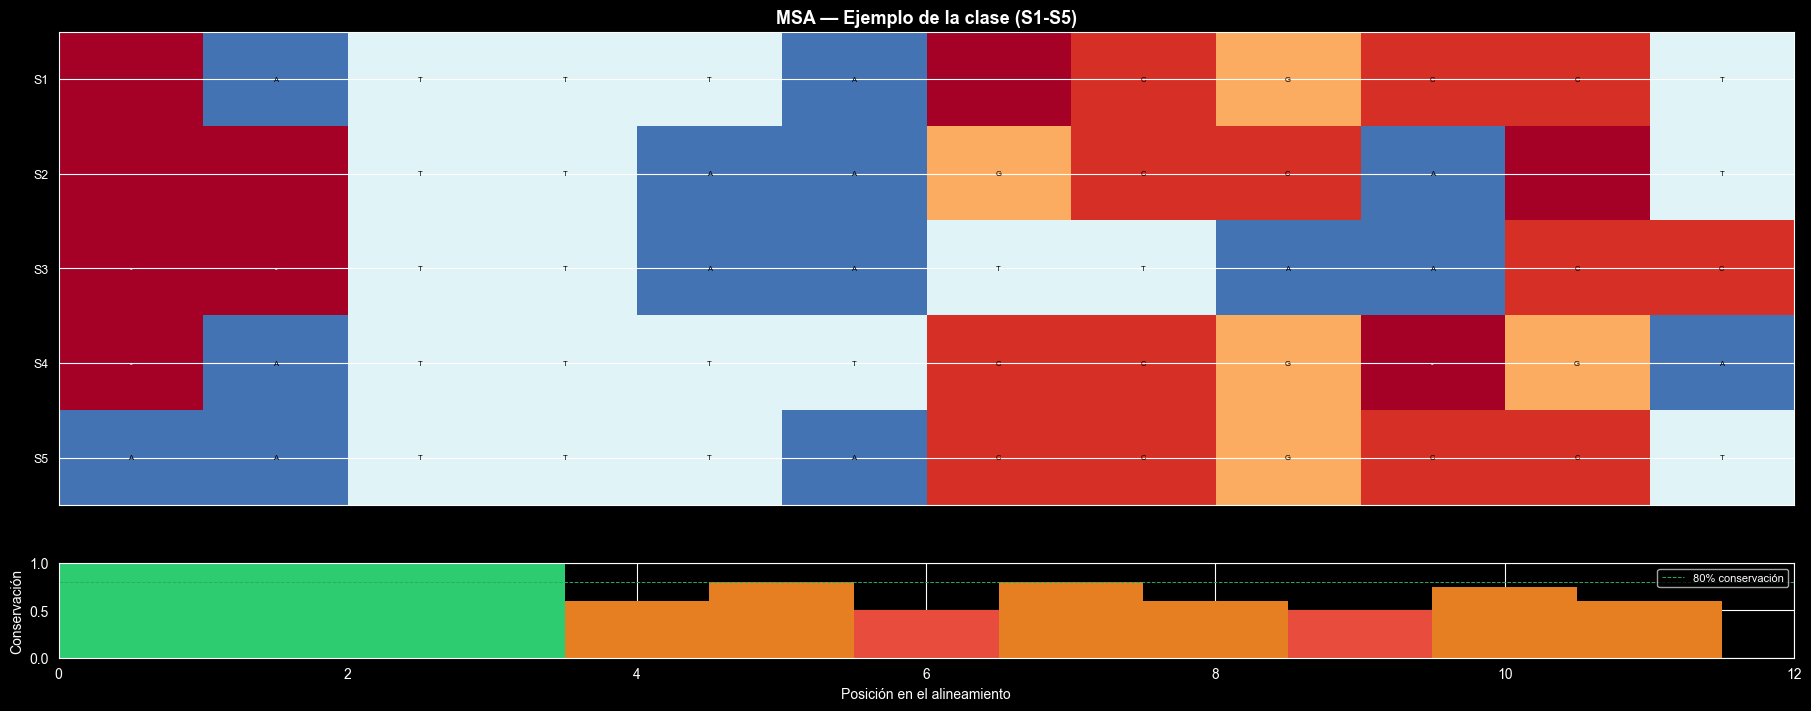

  Longitud MSA        : 12 nt
  Posiciones conservadas (≥80%): 6 (50.0%)
  Conservación media  : 76.2%


In [12]:
def visualizar_msa(resultado: dict[str, str], titulo: str = "MSA"):
    """
    Visualiza el alineamiento múltiple con:
    - Heatmap de identidad (azul=conservado, rojo=variable)
    - Porcentaje de conservación por posición
    - Secuencias alineadas con texto
    """
    nombres_r = list(resultado.keys())
    seqs_r    = [resultado[n] for n in nombres_r]
    N_r = len(seqs_r)
    L_r = len(seqs_r[0])

    # Matriz de identidad: 1 si todos coinciden, 0 si no
    conservacion = []
    for pos in range(L_r):
        col  = [s[pos] for s in seqs_r]
        no_gap = [c for c in col if c != '-']
        if not no_gap:
            conservacion.append(0.0)
            continue
        base_may = max(set(no_gap), key=no_gap.count)
        conservacion.append(no_gap.count(base_may) / len(no_gap))

    # Matriz numérica para el heatmap
    base_map = {'A':0.9, 'T':0.6, 'G':0.3, 'C':0.1, '-':0.0}
    mat = np.array([[base_map.get(s[pos], 0.5) for pos in range(L_r)]
                    for s in seqs_r])

    fig = plt.figure(figsize=(18, 5 + N_r*0.4), layout="constrained")
    gs  = plt.GridSpec(2, 1, height_ratios=[N_r, 1], hspace=0.15, figure=fig)

    # Panel 1: heatmap de bases
    ax1 = fig.add_subplot(gs[0])
    ax1.imshow(mat, cmap='RdYlBu', aspect='auto', vmin=0, vmax=1)
    ax1.set_yticks(range(N_r))
    ax1.set_yticklabels(nombres_r, fontsize=9)
    ax1.set_xticks([])
    ax1.set_title(titulo, fontsize=13, fontweight='bold')
    for i, seq in enumerate(seqs_r):
        for j, c in enumerate(seq[:80]):   # solo primeros 80 para legibilidad
            ax1.text(j, i, c, ha='center', va='center', fontsize=5.5,
                     color='white' if c == '-' else 'black')

    # Panel 2: conservación por posición
    ax2 = fig.add_subplot(gs[1])
    x = range(L_r)
    ax2.bar(x, conservacion, color=['#2ecc71' if c > 0.8 else
                                     '#e67e22' if c > 0.5 else
                                     '#e74c3c' for c in conservacion],
            width=1.0, edgecolor='none')
    ax2.set_xlim(0, L_r)
    ax2.set_ylim(0, 1)
    ax2.set_xlabel("Posición en el alineamiento")
    ax2.set_ylabel("Conservación")
    ax2.axhline(0.8, color='#27ae60', linestyle='--', linewidth=0.7,
                label='80% conservación')
    ax2.legend(fontsize=8)

    plt.savefig(f"data/msa_{titulo.replace(' ','_')}.png", dpi=130, bbox_inches='tight')
    plt.show()

    # Estadísticas
    muy_conservadas = sum(1 for c in conservacion if c >= 0.8)
    print(f"  Longitud MSA        : {L_r} nt")
    print(f"  Posiciones conservadas (≥80%): {muy_conservadas} ({muy_conservadas/L_r*100:.1f}%)")
    print(f"  Conservación media  : {np.mean(conservacion)*100:.1f}%")


visualizar_msa(resultado_demo,  "MSA — Ejemplo de la clase (S1-S5)")


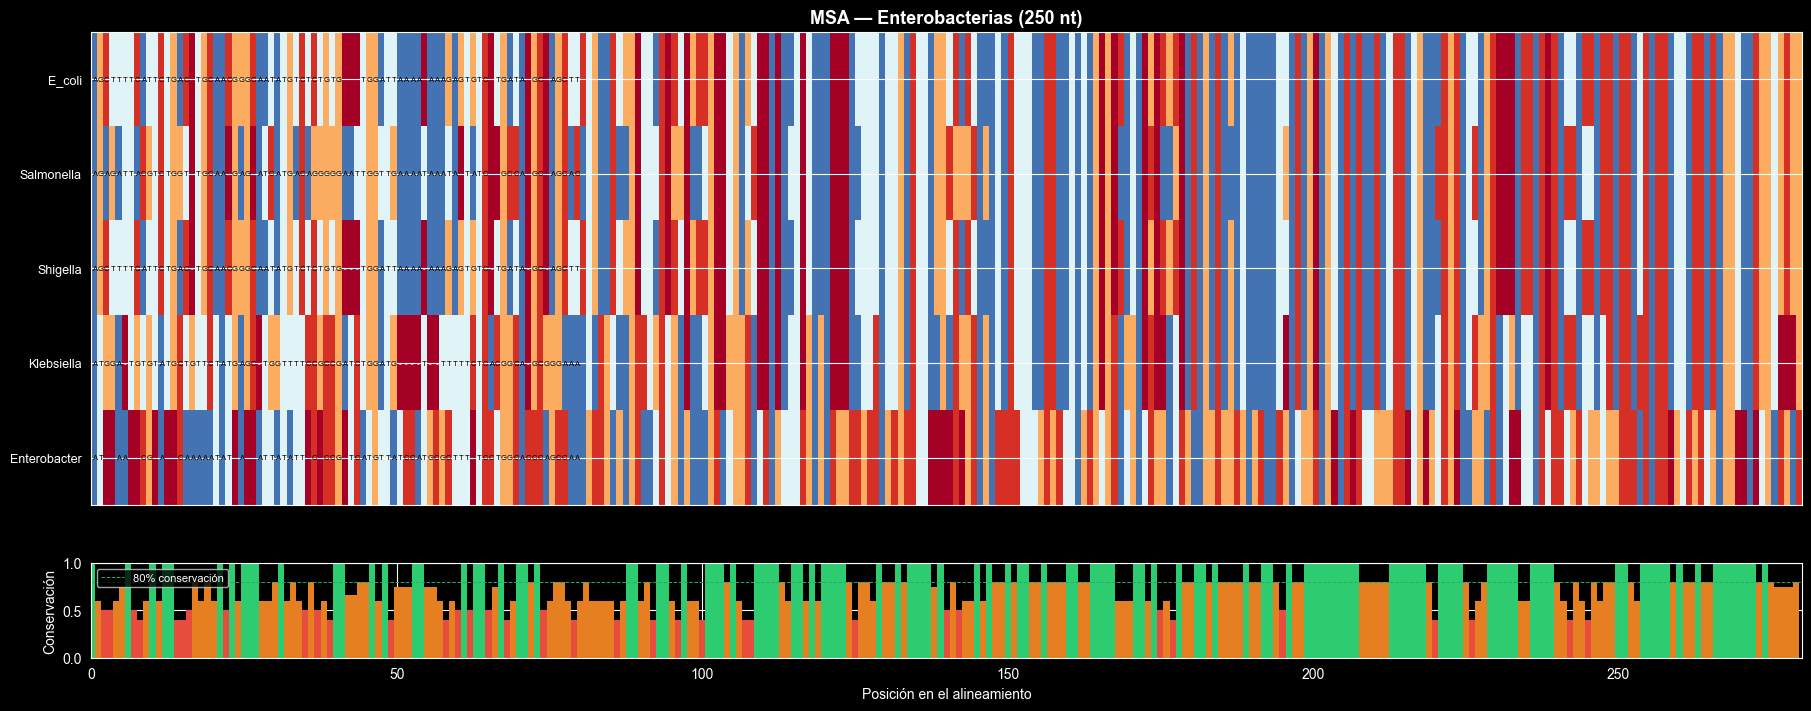

  Longitud MSA        : 280 nt
  Posiciones conservadas (≥80%): 184 (65.7%)
  Conservación media  : 80.3%

Alineamiento final — todas las secuencias de la misma longitud:

  E_coli         : AGCTTTTCATTCTGAC-TGCAACGGGCAATATGTCTCTGTG---TGGATTAAAA-AAAGAGTGTC-TGATA-GC-AGCTTCTGAACTGG-TTAC-CT-GCCG--TGAGT--A-AAT-TAAA---ATTTTATTGACTTAGGTCACTAAATACTTTAACCAATATAG-G-CATA-G-CGC-ACAGACAGATAAAAATTACAG-AGTACACAACATCCATGAAACGCATTAGC---ACCAC-CATTACCACCACCATCACCATTACCACAGGTAACGGTGCGG
  Salmonella     : AGAGATTACGTCTGGT-TGCAA-GAG-ATCATGACAGGGGGAATTGGTTGAAAATAAATA-TATC--GCCA-GC-AGCACATGAACAAG-TTTC-GG-AATG--TGATC--A-ATT-TAAA---AATTTATTGACTTAGGCGGGCAGATACTTTAACCAATATAG-G-AATA-C-AAG-ACAGACAAATAAAAATGACAG-AGTACACAACATCCATGAACCGCATCAGC---ACCAC-CACCATTACCACCATCACCATTACCACAGGTAACGGTGCGG
  Shigella       : AGCTTTTCATTCTGAC-TGCAACGGGCAATATGTCTCTGTG---TGGATTAAAA-AAAGAGTGTC-TGATA-GC-AGCTTCTGAACTGG-TTAC-CT-GCCG--TGAGT--A-AAT-TAAA---ATTTTATTGACTTAGGTCACTAAATACTTTAACCAATATAG-G-CATA-G-CGC-ACAGACAGATAAAAATTACAG-AGTACACA

In [13]:
visualizar_msa(resultado_real, "MSA — Enterobacterias (250 nt)")

# Mostrar MSA final completo (Ejercicio 6: remover X y mostrar alineadas)
print()
print("Alineamiento final — todas las secuencias de la misma longitud:")
print()
L_final = len(next(iter(resultado_real.values())))
for nombre, seq in resultado_real.items():
    print(f"  {nombre:<15}: {seq}")
print()
print(f"  Longitud uniforme: {L_final} nt  ✓")


### Score SP y análisis de conservación

Score SP — Ejemplo de la clase:
  Total SP: -62

Score SP — Secuencias reales:
  Total SP: -1133
  SP medio por columna: -4.046


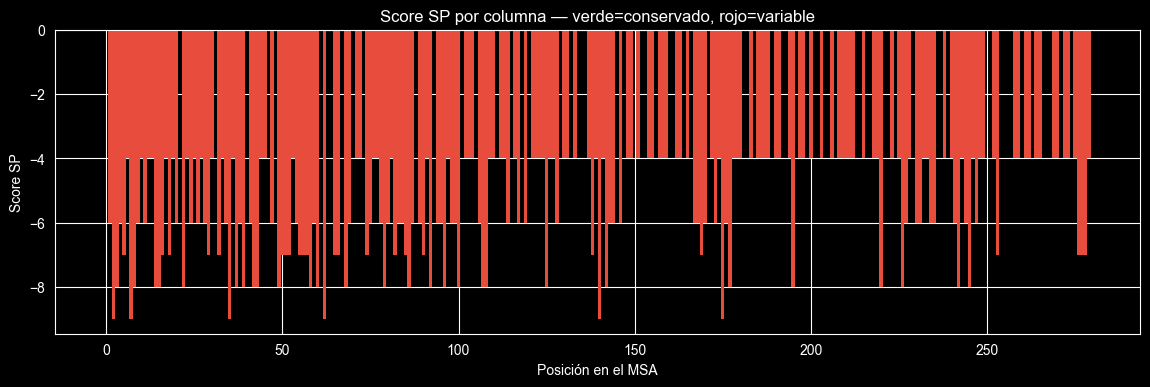

In [14]:
def calcular_sp(resultado: dict[str, str], params: ScoreParams) -> dict:
    """Calcula el Score SP (Sum of Pairs) del MSA."""
    seqs_r = list(resultado.values())
    L_r    = len(seqs_r[0])
    sp_total = 0
    sp_cols  = []
    for pos in range(L_r):
        col    = [s[pos] for s in seqs_r]
        sp_col = 0
        for i in range(len(col)):
            for j in range(i+1, len(col)):
                sp_col += params.score(col[i], col[j])
        sp_cols.append(sp_col)
        sp_total += sp_col
    return {"total": sp_total, "por_columna": sp_cols}


sp_demo = calcular_sp(resultado_demo, params)
sp_real = calcular_sp(resultado_real, params)

print("Score SP — Ejemplo de la clase:")
print(f"  Total SP: {sp_demo['total']}")
print()
print("Score SP — Secuencias reales:")
print(f"  Total SP: {sp_real['total']}")
print(f"  SP medio por columna: {np.mean(sp_real['por_columna']):.3f}")

# Gráfica SP por columna
fig, ax = plt.subplots(figsize=(14, 4))
cols = sp_real['por_columna']
colores = ['#2ecc71' if c > 0 else '#e74c3c' for c in cols]
ax.bar(range(len(cols)), cols, color=colores, width=1.0, edgecolor='none')
ax.axhline(0, color='black', linewidth=0.5)
ax.set_xlabel("Posición en el MSA")
ax.set_ylabel("Score SP")
ax.set_title("Score SP por columna — verde=conservado, rojo=variable")
plt.subplots_adjust(bottom=0.12)
plt.show()


## Conclusiones

1. **Árbol guía UPGMA** — el algoritmo de agrupamiento jerárquico permite
   determinar el orden óptimo de fusión de secuencias. Las secuencias más
   similares se alinean primero, mejorando la calidad del MSA final.

2. **Símbolo neutro X** — durante el proceso progresivo los gaps se
   representan con X para que no acumulen penalización en pasos posteriores.
   Al final se reemplazan por `-` para obtener el formato estándar.

3. **Score SP (Sum of Pairs)** — mide la calidad del MSA sumando las
   puntuaciones de todos los pares de bases en cada columna. Columnas
   conservadas tienen SP positivo; columnas con gaps tienen SP negativo.

4. **Relaciones evolutivas** — las enterobacterias analizadas (*E. coli*,
   *Salmonella*, *Shigella*, *Klebsiella*, *Enterobacter*) comparten
   regiones conservadas al inicio del genoma, reflejando su origen evolutivo
   común dentro de la familia *Enterobacteriaceae*.

5. **Limitación de complejidad** — el MSA por programación dinámica exacta
   tiene complejidad O(2^n × L^n). El enfoque progresivo reduce esto a
   O(n² × L²) a costa de no garantizar el óptimo global.

## Referencias

- Notredame, C. (2002). *Recent progress in multiple sequence alignment.*
  Pharmacogenomics, 3(1), 131-144.
- Thompson, J.D. et al. (1994). *CLUSTAL W.* Nucleic Acids Research, 22(22).
- Durbin, R. et al. (1998). *Biological Sequence Analysis.* Cambridge University Press.
- NCBI E. coli K-12: https://www.ncbi.nlm.nih.gov/nuccore/NC_000913.2
- NCBI Salmonella LT2: https://www.ncbi.nlm.nih.gov/nuccore/NC_003197.2
